In [75]:
import tensorflow as tf
from tensorflow import keras
from keras.models import load_model
from sklearn.model_selection import train_test_split
from keras.layers import  Dense, Flatten, Conv2D, Rescaling, BatchNormalization, MaxPooling2D, Dropout
import matplotlib.pyplot as plt
import os
import pickle
from glob import glob
from tqdm import tqdm
from PIL import Image
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
import random
import cv2
from mtcnn.mtcnn import MTCNN

In [76]:
FOLDER_IMAGES = './datasets/dmd/binary_labels'
INPUT_SHAPE = (180, 180, 3)
BATCH_SIZE = 32
IMG_SIZE = (180, 180)
VAL_SPLIT = 0.2
MODEL_SAVE_FOLDER = './models/cnn/cnn_simple/'
EPOCHS = 30

In [ ]:
def preprocess_crop_image(image_path):
    detector = MTCNN()
    image = cv2.imread(image_path)
    faces = detector.detect_faces(image)
    for face in faces:
        x1, y1, x2, y2 = face['box']
        cropped_image = image[y1:y2, x1:x2]
    return cropped_image

Found 10476 files belonging to 2 classes.
Using 8381 files for training.
Found 10476 files belonging to 2 classes.
Using 2095 files for validation.
['awake', 'drowsy']
(32, 180, 180, 3)
(32,)


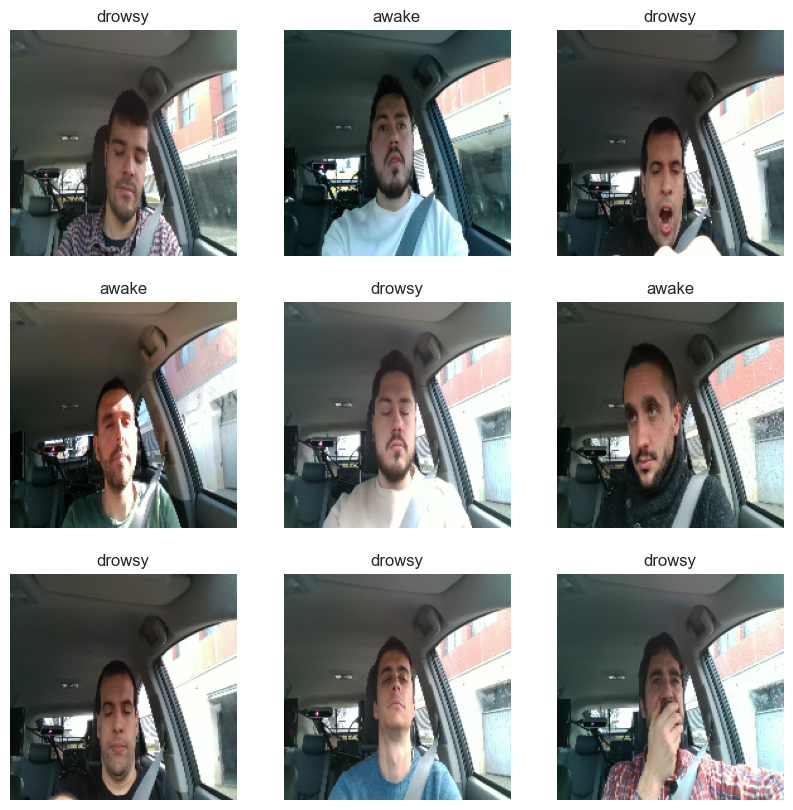

In [77]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  FOLDER_IMAGES,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=IMG_SIZE,
  batch_size=BATCH_SIZE)

val_ds = tf.keras.utils.image_dataset_from_directory(
  FOLDER_IMAGES,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=IMG_SIZE,
  batch_size=BATCH_SIZE)

class_names = train_ds.class_names
num_classes = len(class_names)
print(class_names)

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

In [78]:
if os.path.exists(MODEL_SAVE_FOLDER):
    model = keras.models.load_model(MODEL_SAVE_FOLDER + 'best.h5')
else:
    model = keras.models.Sequential([
        #normalization
        Rescaling(1./255, input_shape=INPUT_SHAPE),

        Conv2D(filters=32, kernel_size=5, strides=1, activation='relu'),
        Conv2D(filters=32, kernel_size=5, strides=1, activation='relu', use_bias=False),
        BatchNormalization(),
        MaxPooling2D(strides=2),
        Dropout(0.3),

        Conv2D(filters=64, kernel_size=3, strides=1, activation='relu'),
        Conv2D(filters=64, kernel_size=3, strides=1, activation='relu', use_bias=False),
        BatchNormalization(),
        MaxPooling2D(strides=2),
        Dropout(0.3),

        Flatten(),
        Dense(units=256, activation='relu', use_bias=False),
        BatchNormalization(),

        Dense(units=128, use_bias=False, activation='relu'),

        Dense(units=84, use_bias=False, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(num_classes, name="outputs")
    ])


    model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), optimizer='adam', metrics=['accuracy'])
    print(model.summary())

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3)

    model_checkpoint = keras.callbacks.ModelCheckpoint(
        filepath=MODEL_SAVE_FOLDER + 'best.h5',
        monitor='val_loss',
        mode='min',
        save_best_only=True,
        verbose=1
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        batch_size=32,
        callbacks=[model_checkpoint]
    )

    with open(MODEL_SAVE_FOLDER + 'model_history.pkl', 'wb') as file:
        pickle.dump(history.history, file)

with open(MODEL_SAVE_FOLDER + 'model_history.pkl', 'rb') as file:
    history = pickle.load(file)
    print(history)

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_6 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d_20 (Conv2D)          (None, 176, 176, 32)      2432      
                                                                 
 conv2d_21 (Conv2D)          (None, 172, 172, 32)      25600     
                                                                 
 batch_normalization_20 (Bat  (None, 172, 172, 32)     128       
 chNormalization)                                                
                                                                 
 max_pooling2d_10 (MaxPoolin  (None, 86, 86, 32)       0         
 g2D)                                                            
                                                                 
 dropout_15 (Dropout)        (None, 86, 86, 32)       

In [79]:
best_model = load_model(MODEL_SAVE_FOLDER + 'best.h5')

In [22]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open(MODEL_SAVE_FOLDER + 'best.tflite', 'wb') as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\david\AppData\Local\Temp\tmpvj3abovx\assets


INFO:tensorflow:Assets written to: C:\Users\david\AppData\Local\Temp\tmpvj3abovx\assets


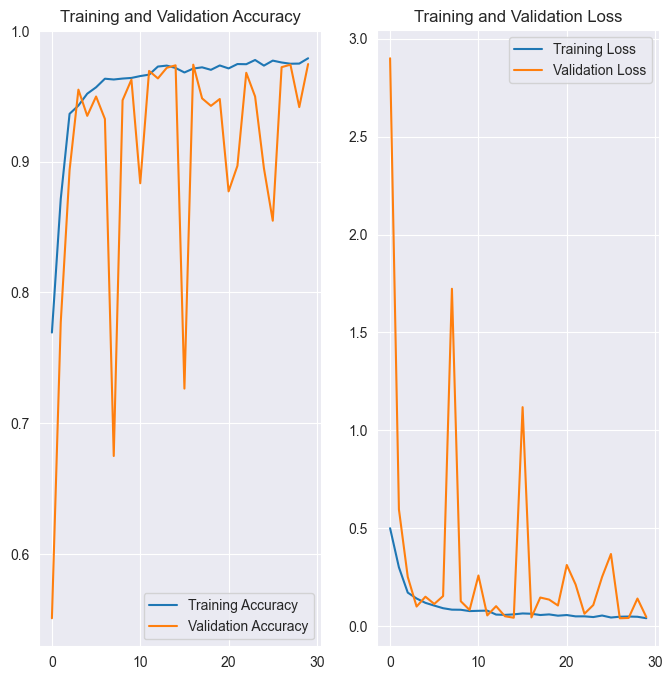

In [81]:
acc = history['accuracy']
val_acc = history['val_accuracy']

loss = history['loss']
val_loss = history['val_loss']

epochs_range = range(30)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

1/1 [==============================] - 0s 16ms/step


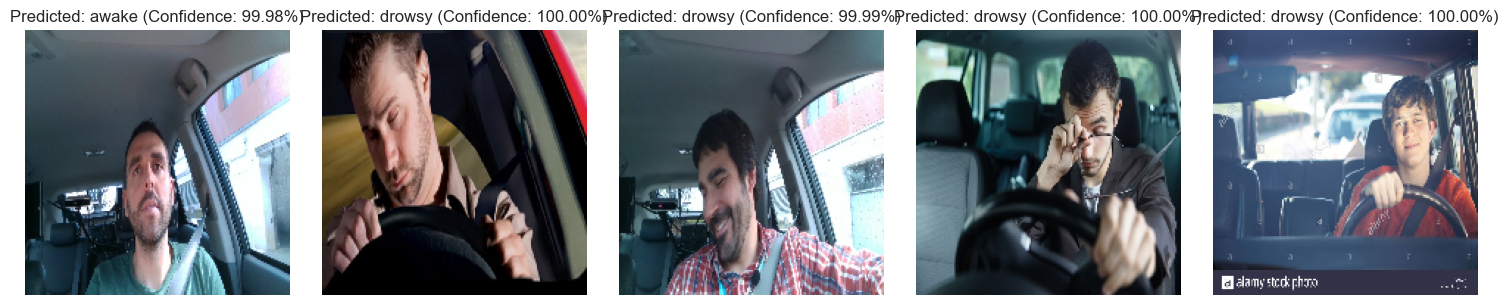

In [82]:
# Select 5 random images
random_images = random.sample(glob('./datasets/dmd/binary_labels_test/*.jpg'), 5)

# Create a grid of subplots
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, image_path in enumerate(random_images):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, 0)  # Create a batch

    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    ax = axes[i]
    ax.imshow(img)
    ax.set_title("Predicted: {} (Confidence: {:.2f}%)".format(class_names[np.argmax(score)], 100 * np.max(score)))
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(15, 5))


# Obtain predictions for the test data
predictions = model.predict(val_ds)
predicted_labels = np.argmax(predictions, axis=1)

# Compute the confusion matrix
cm = confusion_matrix(y_test, predicted_labels)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)